In [1]:
import os
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import ta

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ─── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.')
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
DATA_FEAT    = PROJECT_ROOT / 'data' / 'features'
RESULTS      = PROJECT_ROOT / 'results' / 'plots'

DATA_FEAT.mkdir(parents=True, exist_ok=True)

# ─── Plot Style ───────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

# ─── Commodity Configuration ──────────────────────────────────────────────────
COMMODITIES = {
    'CL=F' : 'WTI_Crude_Oil',
    'GC=F' : 'Gold',
    'NG=F' : 'Natural_Gas',
    'SI=F' : 'Silver',
    'HG=F' : 'Copper'
}
PRIMARY = 'WTI_Crude_Oil'

# ─── Load Processed Data ──────────────────────────────────────────────────────
processed_data = {}
for name in COMMODITIES.values():
    filepath = DATA_PROC / f'{name}_processed.parquet'
    if filepath.exists():
        processed_data[name] = pd.read_parquet(filepath)
        print(f'Loaded {name}: {len(processed_data[name])} rows')
    else:
        print(f'WARNING: {filepath} not found. Run notebook 01 first.')

print(f'\nLoaded {len(processed_data)} commodities.')

Loaded WTI_Crude_Oil: 5217 rows
Loaded Gold: 5217 rows
Loaded Natural_Gas: 5217 rows
Loaded Silver: 5217 rows
Loaded Copper: 5217 rows

Loaded 5 commodities.


In [2]:
def compute_price_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute multi-scale price-based technical indicators.

    Multi-scale design rationale:
    - Short-term (5-21 days): captures recent momentum and mean-reversion
    - Medium-term (21-63 days): captures trend and swing patterns
    - Long-term (63-252 days): captures macro momentum and cycles

    This multi-scale approach is motivated by the commodity forecasting
    literature showing that indicators operating at different timescales
    provide complementary information about price dynamics.
    """
    df = df.copy()
    close  = df['close']
    high   = df['high']
    low    = df['low']
    open_  = df['open']
    volume = df['volume']

    # ── Simple Moving Averages ─────────────────────────────────────────────────
    for window in [5, 10, 21, 50, 100, 200]:
        df[f'sma_{window}'] = close.rolling(window).mean()
        # Price relative to SMA (normalized position)
        df[f'price_to_sma_{window}'] = close / df[f'sma_{window}'] - 1

    # ── Exponential Moving Averages ────────────────────────────────────────────
    for span in [5, 12, 26, 50]:
        df[f'ema_{span}'] = close.ewm(span=span, adjust=False).mean()
        df[f'price_to_ema_{span}'] = close / df[f'ema_{span}'] - 1

    # ── MACD ───────────────────────────────────────────────────────────────────
    macd_indicator = ta.trend.MACD(
        close, window_slow=26, window_fast=12, window_sign=9
    )
    df['macd']         = macd_indicator.macd()
    df['macd_signal']  = macd_indicator.macd_signal()
    df['macd_diff']    = macd_indicator.macd_diff()
    df['macd_cross']   = np.sign(df['macd_diff'])  # +1 bullish, -1 bearish

    # ── RSI (multiple timeframes) ──────────────────────────────────────────────
    for window in [7, 14, 21]:
        rsi = ta.momentum.RSIIndicator(close, window=window)
        df[f'rsi_{window}'] = rsi.rsi()
        # Normalized to [-1, 1]: overbought = positive, oversold = negative
        df[f'rsi_{window}_norm'] = (df[f'rsi_{window}'] - 50) / 50

    # ── Bollinger Bands ────────────────────────────────────────────────────────
    for window in [20, 50]:
        bb = ta.volatility.BollingerBands(
            close, window=window, window_dev=2
        )
        df[f'bb_upper_{window}']  = bb.bollinger_hband()
        df[f'bb_lower_{window}']  = bb.bollinger_lband()
        df[f'bb_mid_{window}']    = bb.bollinger_mavg()
        df[f'bb_width_{window}']  = bb.bollinger_wband()   # Band width
        df[f'bb_pct_{window}']    = bb.bollinger_pband()   # % position within bands

    # ── Stochastic Oscillator ─────────────────────────────────────────────────
    stoch = ta.momentum.StochasticOscillator(
        high, low, close, window=14, smooth_window=3
    )
    df['stoch_k']   = stoch.stoch()
    df['stoch_d']   = stoch.stoch_signal()
    df['stoch_diff'] = df['stoch_k'] - df['stoch_d']

    # ── CCI (Commodity Channel Index) ─────────────────────────────────────────
    for window in [14, 20]:
        cci = ta.trend.CCIIndicator(high, low, close, window=window)
        df[f'cci_{window}'] = cci.cci()

    # ── Williams %R ───────────────────────────────────────────────────────────
    wr = ta.momentum.WilliamsRIndicator(high, low, close, lbp=14)
    df['williams_r'] = wr.williams_r()

    # ── Rate of Change ────────────────────────────────────────────────────────
    for window in [1, 5, 10, 21, 63]:
        df[f'roc_{window}'] = ta.momentum.ROCIndicator(
            close, window=window
        ).roc()

    # ── Price Position ────────────────────────────────────────────────────────
    # Where is current price within its N-day range? [0, 1]
    for window in [21, 63, 252]:
        roll_max = high.rolling(window).max()
        roll_min = low.rolling(window).min()
        df[f'price_position_{window}'] = (
            (close - roll_min) / (roll_max - roll_min + 1e-10)
        )

    # ── Gap Features ──────────────────────────────────────────────────────────
    df['overnight_gap']  = open_ / close.shift(1) - 1  # Gap open vs prev close
    df['intraday_range'] = (high - low) / close         # Normalized intraday range
    df['close_position'] = (close - low) / (high - low + 1e-10)  # Close within day

    return df


# ─── Apply Price Features ─────────────────────────────────────────────────────
print('Computing price-based technical indicators...')
feature_data = {}

for name, df in processed_data.items():
    feature_data[name] = compute_price_features(df)
    n_new = len(feature_data[name].columns) - len(df.columns)
    print(f'  {name}: +{n_new} price features')

print('Price features complete.')

Computing price-based technical indicators...
  WTI_Crude_Oil: +57 price features
  Gold: +57 price features
  Natural_Gas: +57 price features
  Silver: +57 price features
  Copper: +57 price features
Price features complete.


In [3]:
def compute_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute volatility features across multiple timescales.

    Volatility regime identification is critical for the
    regime-conditioned critic in ARA-PPO. These features
    serve as inputs to the gating network.
    """
    df   = df.copy()
    close = df['close']
    high  = df['high']
    low   = df['low']
    open_ = df['open']

    log_ret = df['log_return']

    # ── Realized Volatility (multi-scale) ─────────────────────────────────────
    for window in [5, 10, 21, 63]:
        df[f'realized_vol_{window}d'] = (
            log_ret.rolling(window).std() * np.sqrt(252)
        )

    # ── Parkinson Volatility (uses High-Low range) ────────────────────────────
    # More efficient estimator than close-to-close
    for window in [10, 21]:
        hl_ratio = np.log(high / low) ** 2
        df[f'parkinson_vol_{window}d'] = np.sqrt(
            hl_ratio.rolling(window).mean() / (4 * np.log(2)) * 252
        )

    # ── Garman-Klass Volatility ────────────────────────────────────────────────
    # Uses OHLC data for more accurate intraday volatility estimation
    for window in [10, 21]:
        gk = (
            0.5 * np.log(high / low) ** 2 -
            (2 * np.log(2) - 1) * np.log(close / open_) ** 2
        )
        df[f'gk_vol_{window}d'] = np.sqrt(gk.rolling(window).mean() * 252)

    # ── Volatility Ratio (short/long) ─────────────────────────────────────────
    # > 1: vol expanding (turbulent), < 1: vol contracting (calm)
    df['vol_ratio_5_21']   = df['realized_vol_5d']  / df['realized_vol_21d']
    df['vol_ratio_21_63']  = df['realized_vol_21d'] / df['realized_vol_63d']

    # ── Volatility Regime Classification ─────────────────────────────────────
    # Classify into low/medium/high volatility regime using rolling percentile
    vol_21    = df['realized_vol_21d']
    vol_pct   = vol_21.rolling(252).rank(pct=True)
    df['vol_regime'] = pd.cut(
        vol_pct,
        bins=[0, 0.33, 0.67, 1.0],
        labels=[0, 1, 2]   # 0=low, 1=medium, 2=high
    ).astype(float)

    # ── ATR (Average True Range) ──────────────────────────────────────────────
    for window in [7, 14, 21]:
        atr = ta.volatility.AverageTrueRange(
            high, low, close, window=window
        )
        df[f'atr_{window}']      = atr.average_true_range()
        df[f'atr_{window}_norm'] = df[f'atr_{window}'] / close  # Normalized ATR

    # ── Volatility of Volatility ──────────────────────────────────────────────
    df['vol_of_vol_21'] = df['realized_vol_21d'].rolling(21).std()

    # ── GARCH(1,1) Proxy ──────────────────────────────────────────────────────
    # Simple exponentially weighted variance as GARCH proxy
    # More accurate GARCH would require arch library fitting per window
    df['ewm_variance']      = log_ret.ewm(span=21).var() * 252
    df['ewm_vol']           = np.sqrt(df['ewm_variance'])

    # ── Volatility Surprise ───────────────────────────────────────────────────
    # Difference between realized and expected volatility
    df['vol_surprise'] = df['realized_vol_5d'] - df['realized_vol_21d']

    return df


# ─── Apply Volatility Features ────────────────────────────────────────────────
print('Computing volatility features...')
for name in feature_data:
    prev_cols = len(feature_data[name].columns)
    feature_data[name] = compute_volatility_features(feature_data[name])
    n_new = len(feature_data[name].columns) - prev_cols
    print(f'  {name}: +{n_new} volatility features')

print('Volatility features complete.')

Computing volatility features...
  WTI_Crude_Oil: +21 volatility features
  Gold: +21 volatility features
  Natural_Gas: +21 volatility features
  Silver: +21 volatility features
  Copper: +21 volatility features
Volatility features complete.


In [4]:
def compute_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute volume-based features.

    Volume is a key market microstructure signal in commodity
    futures — unusual volume often precedes price moves and
    is particularly informative around contract roll dates.
    """
    df     = df.copy()
    close  = df['close']
    high   = df['high']
    low    = df['low']
    volume = df['volume']

    # ── Volume Moving Averages ────────────────────────────────────────────────
    for window in [5, 10, 21]:
        df[f'volume_sma_{window}'] = volume.rolling(window).mean()

    # ── Relative Volume ───────────────────────────────────────────────────────
    # Volume relative to recent average: > 1 = above average activity
    df['rel_volume_5']  = volume / (df['volume_sma_5']  + 1)
    df['rel_volume_21'] = volume / (df['volume_sma_21'] + 1)

    # ── Volume Momentum ───────────────────────────────────────────────────────
    df['volume_roc_5']  = volume.pct_change(5)
    df['volume_roc_21'] = volume.pct_change(21)

    # ── On-Balance Volume ─────────────────────────────────────────────────────
    obv = ta.volume.OnBalanceVolumeIndicator(close, volume)
    df['obv']       = obv.on_balance_volume()
    df['obv_sma21'] = df['obv'].rolling(21).mean()
    df['obv_signal'] = df['obv'] - df['obv_sma21']  # OBV vs its MA

    # ── Volume Price Trend ────────────────────────────────────────────────────
    vpt = ta.volume.VolumePriceTrendIndicator(close, volume)
    df['vpt'] = vpt.volume_price_trend()

    # ── Chaikin Money Flow ────────────────────────────────────────────────────
    cmf = ta.volume.ChaikinMoneyFlowIndicator(
        high, low, close, volume, window=20
    )
    df['cmf'] = cmf.chaikin_money_flow()

    # ── Volume-Weighted Price Ratio ───────────────────────────────────────────
    # Proxy for VWAP using rolling window
    df['vwap_ratio_21'] = (
        (close * volume).rolling(21).sum() /
        (volume.rolling(21).sum() + 1)
    )
    df['price_to_vwap'] = close / df['vwap_ratio_21'] - 1

    # ── Price-Volume Divergence ───────────────────────────────────────────────
    # Correlation between price return and volume change over short window
    # Negative correlation: price up on low volume = weak signal
    df['pv_corr_10'] = (
        df['log_return'].rolling(10)
        .corr(volume.pct_change())
    )

    return df


# ─── Apply Volume Features ────────────────────────────────────────────────────
print('Computing volume features...')
for name in feature_data:
    prev_cols = len(feature_data[name].columns)
    feature_data[name] = compute_volume_features(feature_data[name])
    n_new = len(feature_data[name].columns) - prev_cols
    print(f'  {name}: +{n_new} volume features')

print('Volume features complete.')

Computing volume features...
  WTI_Crude_Oil: +15 volume features
  Gold: +15 volume features
  Natural_Gas: +15 volume features
  Silver: +15 volume features
  Copper: +15 volume features
Volume features complete.


In [5]:
def compute_curve_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute futures curve shape and roll-related features.

    Rationale from thesis Section 2.5.1:
    The futures curve shape (contango vs backwardation) encodes
    fundamental supply-demand balance. Roll yield is a significant
    component of commodity returns that distinguishes commodity
    futures from spot price dynamics.

    Since we use Yahoo Finance continuous front-month futures
    (no full curve data), these are proxy measures based on
    price momentum and term structure inference.
    """
    df = df.copy()

    # ── Term Structure Proxies ────────────────────────────────────────────────
    # Short vs long momentum divergence proxies curve slope
    # Positive = backwardation tendency (spot premium)
    # Negative = contango tendency (futures premium)
    df['curve_slope_1_3m']   = df['momentum_1m']  - df['momentum_3m']  / 3
    df['curve_slope_1_6m']   = df['momentum_1m']  - df['momentum_6m']  / 6
    df['curve_slope_3_12m']  = df['momentum_3m']  - df['momentum_12m'] / 4

    # ── Contango/Backwardation Signal ─────────────────────────────────────────
    # Binary classification: 1 = backwardation, -1 = contango
    df['contango_signal']    = np.sign(df['curve_slope_1_3m'])

    # ── Roll Yield Proxy ──────────────────────────────────────────────────────
    # Annualized roll yield approximation
    df['roll_yield_proxy']   = df['curve_slope_1_3m'] * 4  # Annualized

    # ── Carry Signal ──────────────────────────────────────────────────────────
    # Smoothed roll yield proxy as a carry signal
    df['carry_signal_21d']   = df['roll_yield_proxy'].rolling(21).mean()
    df['carry_signal_63d']   = df['roll_yield_proxy'].rolling(63).mean()

    # ── Basis Volatility ──────────────────────────────────────────────────────
    # Volatility of the curve slope signal
    df['curve_vol_21d']      = df['curve_slope_1_3m'].rolling(21).std()

    # ── Seasonality Features ──────────────────────────────────────────────────
    # Monthly seasonality encoded as sin/cos (avoids discontinuity at year boundary)
    month = df.index.month
    df['month_sin']          = np.sin(2 * np.pi * month / 12)
    df['month_cos']          = np.cos(2 * np.pi * month / 12)

    # Quarter encoding
    quarter = df.index.quarter
    df['quarter_sin']        = np.sin(2 * np.pi * quarter / 4)
    df['quarter_cos']        = np.cos(2 * np.pi * quarter / 4)

    # Day of week (trading patterns differ by weekday)
    dow = df.index.dayofweek
    df['dow_sin']            = np.sin(2 * np.pi * dow / 5)
    df['dow_cos']            = np.cos(2 * np.pi * dow / 5)

    # ── Days to typical roll date ─────────────────────────────────────────────
    # WTI front-month expires ~3rd business day before 25th of month
    # We encode proximity to end of month as a roll pressure signal
    days_in_month     = df.index.days_in_month
    day_of_month      = df.index.day
    df['days_to_eom'] = days_in_month - day_of_month
    df['roll_period'] = (df['days_to_eom'] <= 5).astype(int)  # Near roll date

    return df


# ─── Apply Curve Features ─────────────────────────────────────────────────────
print('Computing futures curve and calendar features...')
for name in feature_data:
    prev_cols = len(feature_data[name].columns)
    feature_data[name] = compute_curve_features(feature_data[name])
    n_new = len(feature_data[name].columns) - prev_cols
    print(f'  {name}: +{n_new} curve/calendar features')

print('Curve features complete.')

Computing futures curve and calendar features...
  WTI_Crude_Oil: +16 curve/calendar features


  Gold: +16 curve/calendar features
  Natural_Gas: +16 curve/calendar features
  Silver: +16 curve/calendar features
  Copper: +16 curve/calendar features
Curve features complete.


In [6]:
def compute_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Continuous market regime features.

    Previous implementation (v1) quantized all four regime signals into
    categorical buckets (2-3 discrete values each), destroying the gradient
    signal through the regime-aware gating/routing networks. This version
    uses continuous, z-scored, bounded signals that preserve magnitude
    information and give smooth gradients to downstream networks.

    All features are:
      - Continuous (hundreds of unique values)
      - Scale-invariant (z-scored against rolling baseline)
      - Bounded (clipped to [-5, 5] to prevent outlier domination)
      - Backward-looking only (no lookahead)
    """
    df    = df.copy()
    close = df['close']

    # ── Trend Direction (these are auxiliary, not the regime vector) ──────────
    df['above_sma50']     = (close > df['sma_50']).astype(int)
    df['above_sma200']    = (close > df['sma_200']).astype(int)
    df['sma50_200_cross'] = np.sign(df['sma_50'] - df['sma_200'])

    # ── ADX (Trend Strength) ──────────────────────────────────────────────────
    adx = ta.trend.ADXIndicator(
        df['high'], df['low'], close, window=14
    )
    df['adx']       = adx.adx()
    df['adx_pos']   = adx.adx_pos()
    df['adx_neg']   = adx.adx_neg()
    df['adx_diff']  = df['adx_pos'] - df['adx_neg']

    # REPLACED: was pd.cut into 3 buckets. Now continuous, z-scored.
    # ADX is naturally 0-100. Center it at the historical median and scale.
    adx_median_252 = df['adx'].rolling(252, min_periods=63).median()
    adx_iqr_252   = (
        df['adx'].rolling(252, min_periods=63).quantile(0.75)
      - df['adx'].rolling(252, min_periods=63).quantile(0.25)
    )
    df['trend_strength'] = (
        (df['adx'] - adx_median_252) / (adx_iqr_252 + 1e-8)
    ).clip(-5, 5)

    # ── Mean Reversion Signal ─────────────────────────────────────────────────
    for window in [21, 63]:
        roll_mean = close.rolling(window).mean()
        roll_std  = close.rolling(window).std()
        df[f'price_zscore_{window}'] = (
            (close - roll_mean) / (roll_std + 1e-10)
        ).clip(-5, 5)

    # ── Hurst Exponent Proxy ──────────────────────────────────────────────────
    def rolling_hurst_proxy(series, window=63):
        k     = 5
        var_1 = series.rolling(window).var()
        var_k = series.rolling(window * k).var()
        vr    = var_k / (var_1 * k + 1e-10)
        return 0.5 + 0.5 * np.tanh(vr - 1)

    df['hurst_proxy'] = rolling_hurst_proxy(df['log_return'])

    # ── Momentum Composite ────────────────────────────────────────────────────
    # REPLACED: was sum of np.sign() — threw away magnitude, produced 13 buckets.
    # Now: magnitude-preserving weighted combination, z-scored.
    mom_raw = (
        df['momentum_1m'] * 0.4 +
        df['momentum_3m'] * 0.35 +
        df['momentum_6m'] * 0.25
    )
    mom_mean_252 = mom_raw.rolling(252, min_periods=63).mean()
    mom_std_252  = mom_raw.rolling(252, min_periods=63).std()
    df['momentum_composite'] = (
        (mom_raw - mom_mean_252) / (mom_std_252 + 1e-8)
    ).clip(-5, 5)

    # ──────────────────────────────────────────────────────────────────────────
    # ── 4-D REGIME STATE VECTOR (continuous, passed to router network) ────────
    # ──────────────────────────────────────────────────────────────────────────

    # 1. regime_vol — continuous volatility percentile rank (from cell 2)
    #    REPLACED: was pd.cut into {0,1,2}. `realized_vol_21d` already has a
    #    continuous rolling percentile computed in cell 2 as `vol_pct`, but
    #    that variable is local. Recompute here and keep continuous.
    vol_21  = df['realized_vol_21d']
    vol_pct = vol_21.rolling(252, min_periods=63).rank(pct=True)
    # Center at 0.5 (median), scale to roughly [-1, +1]
    df['regime_vol'] = ((vol_pct - 0.5) * 2.0).clip(-1.0, 1.0)

    # 2. regime_trend — continuous trend strength z-score (computed above)
    df['regime_trend'] = df['trend_strength']

    # 3. regime_momentum — continuous z-scored momentum (computed above)
    df['regime_momentum'] = df['momentum_composite']

    # 4. regime_curve — continuous curve slope, z-scored
    #    REPLACED: was np.sign(curve_slope_1_3m) → binary {-1, +1}.
    #    Now: z-score of the continuous curve_slope_1_3m itself.
    cs = df['curve_slope_1_3m']
    cs_mean_252 = cs.rolling(252, min_periods=63).mean()
    cs_std_252  = cs.rolling(252, min_periods=63).std()
    df['regime_curve'] = (
        (cs - cs_mean_252) / (cs_std_252 + 1e-8)
    ).clip(-5, 5)

    return df


# ─── Apply Regime Features ────────────────────────────────────────────────────
print('Computing market regime features (CONTINUOUS v2)...')
for name in feature_data:
    prev_cols = len(feature_data[name].columns)
    feature_data[name] = compute_regime_features(feature_data[name])
    n_new = len(feature_data[name].columns) - prev_cols
    print(f'  {name}: +{n_new} regime features')

# ─── Verify continuity of regime signals ──────────────────────────────────────
print('\nRegime feature continuity check:')
for name, data in feature_data.items():
    print(f'\n  {name}:')
    for feat in ['regime_vol', 'regime_trend', 'regime_momentum', 'regime_curve']:
        if feat in data.columns:
            col = data[feat].dropna()
            n_unique = col.nunique()
            status   = '✓' if n_unique > 100 else '✗ STILL CATEGORICAL'
            print(f'    {feat:<20s} n_unique={n_unique:>6d}  '
                  f'min={col.min():+.3f}  max={col.max():+.3f}  '
                  f'std={col.std():.3f}  {status}')

print('\nRegime features complete.')

Computing market regime features (CONTINUOUS v2)...
  WTI_Crude_Oil: +16 regime features
  Gold: +16 regime features
  Natural_Gas: +16 regime features
  Silver: +16 regime features
  Copper: +16 regime features

Regime feature continuity check:

  WTI_Crude_Oil:
    regime_vol           n_unique=   589  min=-0.992  max=+1.000  std=0.621  ✓
    regime_trend         n_unique=  5155  min=-2.448  max=+3.476  std=0.790  ✓
    regime_momentum      n_unique=  5027  min=-5.000  max=+4.249  std=1.217  ✓
    regime_curve         n_unique=  5088  min=-5.000  max=+5.000  std=1.049  ✓

  Gold:
    regime_vol           n_unique=   416  min=-0.992  max=+1.000  std=0.632  ✓
    regime_trend         n_unique=  5153  min=-1.819  max=+3.491  std=0.815  ✓
    regime_momentum      n_unique=  5029  min=-3.726  max=+4.409  std=1.169  ✓
    regime_curve         n_unique=  5092  min=-4.198  max=+4.367  std=1.052  ✓

  Natural_Gas:
    regime_vol           n_unique=   431  min=-0.992  max=+1.000  std=0.633  ✓


In [7]:
def compute_cross_commodity_features(
    data    : dict,
    primary : str = 'WTI_Crude_Oil'
) -> dict:
    """
    Compute cross-commodity correlation and spread features.

    Cross-commodity features capture sector-wide dynamics
    that single-asset models cannot observe. Energy complex
    correlations (WTI-Natural Gas), precious metals correlation
    (Gold-Silver), and industrial metals provide regime context.
    """
    # Build aligned return DataFrame
    returns_df = pd.DataFrame({
        name: df['log_return']
        for name, df in data.items()
    }).dropna(how='all')

    # Align all series to primary commodity index
    primary_idx = data[primary].index

    for name in list(data.keys()):
        df = data[name].copy()

        # ── Rolling Correlations with Other Commodities ───────────────────────
        for other_name, other_df in data.items():
            if other_name == name:
                continue

            short_name = other_name.replace('_', '').replace('Crude', '')[:8]

            # Align on common dates
            common_idx = df.index.intersection(other_df.index)

            aligned_self  = df.loc[common_idx, 'log_return']
            aligned_other = other_df.loc[common_idx, 'log_return']

            # Rolling 21-day and 63-day correlation
            roll_corr_21 = aligned_self.rolling(21).corr(aligned_other)
            roll_corr_63 = aligned_self.rolling(63).corr(aligned_other)

            df[f'corr_{short_name}_21d'] = roll_corr_21.reindex(df.index)
            df[f'corr_{short_name}_63d'] = roll_corr_63.reindex(df.index)

            # ── Return Spread ─────────────────────────────────────────────────
            # 21-day cumulative return spread
            self_ret_21  = df['close'].pct_change(21)
            other_ret_21 = other_df['close'].pct_change(21).reindex(df.index)
            df[f'spread_{short_name}_21d'] = self_ret_21 - other_ret_21

        # ── Average Cross-Commodity Correlation ───────────────────────────────
        corr_cols_21 = [c for c in df.columns if c.startswith('corr_') and c.endswith('21d')]
        corr_cols_63 = [c for c in df.columns if c.startswith('corr_') and c.endswith('63d')]

        if corr_cols_21:
            df['avg_cross_corr_21d'] = df[corr_cols_21].mean(axis=1)
        if corr_cols_63:
            df['avg_cross_corr_63d'] = df[corr_cols_63].mean(axis=1)

        data[name] = df

    return data


# ─── Apply Cross-Commodity Features ──────────────────────────────────────────
print('Computing cross-commodity features...')
prev_cols = {name: len(df.columns) for name, df in feature_data.items()}
feature_data = compute_cross_commodity_features(feature_data, PRIMARY)

for name in feature_data:
    n_new = len(feature_data[name].columns) - prev_cols[name]
    print(f'  {name}: +{n_new} cross-commodity features')

print('Cross-commodity features complete.')

Computing cross-commodity features...


  WTI_Crude_Oil: +14 cross-commodity features
  Gold: +14 cross-commodity features
  Natural_Gas: +14 cross-commodity features
  Silver: +14 cross-commodity features
  Copper: +14 cross-commodity features
Cross-commodity features complete.


## Cell 7b: Forward-Looking Calendar Features — Modification 4

**Proactive Regime Conditioning:** Unlike all other features which are backward-looking,
these calendar features inform the agent of scheduled high-volatility events BEFORE
they appear in price data. This directly targets the high-volatility regime failure
identified in the walk-forward evaluation.

**Key events for WTI crude oil:**
- **EIA report** (every Wednesday): largest scheduled volatility event
- **OPEC meetings**: structural price shocks announced months in advance
- **FOMC decisions** (8x/year): affect commodity prices via USD
- **Futures expiry**: roll pressure near contract expiry date

In [8]:
def compute_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute forward-looking calendar features for WTI crude oil.

    Design rationale (Modification 4 — Proactive Regime Conditioning):
    ────────────────────────────────────────────────────────────────────
    All existing ARA-PPO regime features are backward-looking — they
    detect regimes AFTER they appear in price data. These calendar
    features are forward-looking: they tell the agent that a
    high-volatility event is COMING before it materializes in prices.

    This directly addresses the high-volatility failure mode identified
    in the walk-forward evaluation (splits 0, 6, 7, 11).

    Features:
        EIA report    : every Wednesday — largest scheduled vol event for WTI
        OPEC meeting  : announced months in advance — structural price shocks
        FOMC decision : 8x per year — affects commodity prices via USD
        Expiry week   : futures roll pressure near contract expiry
        event_pressure: composite forward event intensity signal
    """
    df = df.copy()

    # ── EIA Weekly Petroleum Status Report ────────────────────────────────────
    # Every Wednesday at 10:30am EST — most important scheduled event for WTI
    dow = df.index.dayofweek
    eia_map = {0: 2.0, 1: 1.0, 2: 0.0, 3: 6.0, 4: 5.0, 5: 4.0, 6: 3.0}
    df['days_to_eia']  = dow.map(eia_map).fillna(7.0)
    df['eia_report_day'] = (df['days_to_eia'] == 0).astype(float)
    # Normalize to [0,1]: 0 = report day, 1 = furthest
    df['days_to_eia_norm'] = df['days_to_eia'] / 7.0

    # ── OPEC Meeting Dates ────────────────────────────────────────────────────
    opec_dates = pd.to_datetime([
        '2005-03-16','2005-06-15','2005-09-19','2005-12-12',
        '2006-01-31','2006-03-08','2006-05-31','2006-10-19','2006-12-14',
        '2007-02-01','2007-03-15','2007-09-11','2007-12-05',
        '2008-02-01','2008-03-05','2008-09-09','2008-10-24','2008-12-17',
        '2009-03-15','2009-05-28','2009-09-09','2009-12-22',
        '2010-03-17','2010-10-14','2010-12-11',
        '2011-06-08','2011-12-14',
        '2012-06-14','2012-12-12',
        '2013-05-31','2013-12-04',
        '2014-06-11','2014-11-27',
        '2015-06-05','2015-12-04',
        '2016-06-02','2016-11-30',
        '2017-05-25','2017-11-30',
        '2018-06-22','2018-12-06',
        '2019-07-01','2019-12-05',
        '2020-03-06','2020-04-09','2020-06-06','2020-11-30',
        '2021-01-04','2021-02-28','2021-03-04','2021-04-01',
        '2021-05-05','2021-06-01','2021-07-01','2021-08-01',
        '2021-09-01','2021-10-04','2021-11-04','2021-12-02',
        '2022-01-04','2022-02-02','2022-03-02','2022-04-05',
        '2022-05-05','2022-06-02','2022-08-03','2022-09-05',
        '2022-10-05','2022-11-04','2022-12-04',
        '2023-01-04','2023-02-01','2023-03-29','2023-04-03',
        '2023-05-04','2023-06-04','2023-08-03','2023-09-04',
        '2023-10-04','2023-11-26','2023-12-30',
        '2024-02-01','2024-03-03','2024-04-03','2024-06-02',
        '2024-08-01','2024-09-05','2024-11-28',
    ])

    # ── FOMC Meeting Dates ────────────────────────────────────────────────────
    fomc_dates = pd.to_datetime([
        '2005-02-02','2005-03-22','2005-05-03','2005-06-30',
        '2005-08-09','2005-09-20','2005-11-01','2005-12-13',
        '2006-01-31','2006-03-28','2006-05-10','2006-06-29',
        '2006-08-08','2006-09-20','2006-10-25','2006-12-12',
        '2007-01-31','2007-03-21','2007-05-09','2007-06-28',
        '2007-08-07','2007-09-18','2007-10-31','2007-12-11',
        '2008-01-22','2008-01-30','2008-03-18','2008-04-30',
        '2008-06-25','2008-08-05','2008-09-16','2008-10-08',
        '2008-10-29','2008-12-16',
        '2009-01-28','2009-03-18','2009-04-29','2009-06-24',
        '2009-08-12','2009-09-23','2009-11-04','2009-12-16',
        '2010-01-27','2010-03-16','2010-04-28','2010-06-23',
        '2010-08-10','2010-09-21','2010-11-03','2010-12-14',
        '2011-01-26','2011-03-15','2011-04-27','2011-06-22',
        '2011-08-09','2011-09-21','2011-11-02','2011-12-13',
        '2012-01-25','2012-03-13','2012-04-25','2012-06-20',
        '2012-08-01','2012-09-13','2012-10-24','2012-12-12',
        '2013-01-30','2013-03-20','2013-05-01','2013-06-19',
        '2013-07-31','2013-09-18','2013-10-30','2013-12-18',
        '2014-01-29','2014-03-19','2014-04-30','2014-06-18',
        '2014-07-30','2014-09-17','2014-10-29','2014-12-17',
        '2015-01-28','2015-03-18','2015-04-29','2015-06-17',
        '2015-07-29','2015-09-17','2015-10-28','2015-12-16',
        '2016-01-27','2016-03-16','2016-04-27','2016-06-15',
        '2016-07-27','2016-09-21','2016-11-02','2016-12-14',
        '2017-02-01','2017-03-15','2017-05-03','2017-06-14',
        '2017-07-26','2017-09-20','2017-11-01','2017-12-13',
        '2018-01-31','2018-03-21','2018-05-02','2018-06-13',
        '2018-08-01','2018-09-26','2018-11-08','2018-12-19',
        '2019-01-30','2019-03-20','2019-05-01','2019-06-19',
        '2019-07-31','2019-09-18','2019-10-30','2019-12-11',
        '2020-01-29','2020-03-03','2020-03-15','2020-04-29',
        '2020-06-10','2020-07-29','2020-09-16','2020-11-05','2020-12-16',
        '2021-01-27','2021-03-17','2021-04-28','2021-06-16',
        '2021-07-28','2021-09-22','2021-11-03','2021-12-15',
        '2022-01-26','2022-03-16','2022-05-04','2022-06-15',
        '2022-07-27','2022-09-21','2022-11-02','2022-12-14',
        '2023-02-01','2023-03-22','2023-05-03','2023-06-14',
        '2023-07-26','2023-09-20','2023-11-01','2023-12-13',
        '2024-01-31','2024-03-20','2024-05-01','2024-06-12',
        '2024-07-31','2024-09-18','2024-11-07','2024-12-18',
    ])

    def days_to_next(date, event_dates, cap=30):
        future = event_dates[event_dates >= date]
        if len(future) == 0:
            return float(cap)
        return float(min((future - date).days[0], cap))

    df['days_to_opec_raw']  = [days_to_next(d, opec_dates) for d in df.index]
    df['days_to_fomc_raw']  = [days_to_next(d, fomc_dates) for d in df.index]

    # Normalize to [0,1]: 0=meeting day, 1=far away
    df['days_to_opec_norm'] = df['days_to_opec_raw'] / 30.0
    df['days_to_fomc_norm'] = df['days_to_fomc_raw'] / 30.0

    # Binary: within 1 week of meeting
    df['opec_meeting_week'] = (df['days_to_opec_raw'] <= 7).astype(float)
    df['fomc_meeting_week'] = (df['days_to_fomc_raw'] <= 7).astype(float)

    # ── Futures Expiry Pressure ───────────────────────────────────────────────
    # WTI front-month expires ~3rd business day before 25th of month
    day_of_month = np.array(df.index.day)
    df['days_to_expiry_norm'] = np.clip(22 - day_of_month, 0, 22) / 22.0
    df['expiry_week'] = (df['days_to_expiry_norm'] <= 5/22).astype(float)

    # ── Composite Event Pressure ──────────────────────────────────────────────
    # Weighted combination of all forward event signals
    # Higher = more scheduled events are imminent
    df['event_pressure'] = (
        (1 - df['days_to_eia_norm'])    * 0.40 +  # EIA most important for WTI
        (1 - df['days_to_opec_norm'])   * 0.35 +  # OPEC second
        (1 - df['days_to_fomc_norm'])   * 0.15 +  # Fed third
        (1 - df['days_to_expiry_norm']) * 0.10    # Expiry fourth
    ).clip(0, 1)

    return df


# ── Apply calendar features ───────────────────────────────────────────────────
print('Computing forward-looking calendar features (Proactive Regime Conditioning)...')
for name in feature_data:
    prev_cols = len(feature_data[name].columns)
    feature_data[name] = compute_calendar_features(feature_data[name])
    n_new = len(feature_data[name].columns) - prev_cols
    print(f'  {name}: +{n_new} calendar features')

# Verify on WTI
wti_sample = feature_data['WTI_Crude_Oil']
print(f'\nCalendar feature verification (WTI last 3 rows):')
cal_cols = ['days_to_eia_norm','eia_report_day','days_to_opec_norm',
            'opec_meeting_week','days_to_fomc_norm','fomc_meeting_week',
            'event_pressure']
print(wti_sample[cal_cols].tail(3).to_string())
print('\nCalendar features complete.')


Computing forward-looking calendar features (Proactive Regime Conditioning)...
  WTI_Crude_Oil: +12 calendar features
  Gold: +12 calendar features
  Natural_Gas: +12 calendar features
  Silver: +12 calendar features
  Copper: +12 calendar features

Calendar feature verification (WTI last 3 rows):
            days_to_eia_norm  eia_report_day  days_to_opec_norm  opec_meeting_week  days_to_fomc_norm  fomc_meeting_week  event_pressure
date                                                                                                                                    
2024-12-27            0.7143          0.0000             1.0000             0.0000             1.0000             0.0000          0.2143
2024-12-30            0.2857          0.0000             1.0000             0.0000             1.0000             0.0000          0.3857
2024-12-31            0.1429          0.0000             1.0000             0.0000             1.0000             0.0000          0.4429

Calendar featur

In [9]:
def analyze_features(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Summarize all features: count, NaN rate, basic stats.
    Identifies the warm-up period required before features are valid.
    """
    # Count NaNs per feature
    nan_counts   = df.isnull().sum()
    nan_pct      = (nan_counts / len(df) * 100).round(2)

    # Find first valid index per feature
    first_valid  = df.apply(lambda x: x.first_valid_index())

    summary = pd.DataFrame({
        'NaN Count' : nan_counts,
        'NaN %'     : nan_pct,
        'First Valid': first_valid
    })

    # Features with high NaN rates are potentially problematic
    high_nan = summary[summary['NaN %'] > 10]

    print(f'\n{name} Feature Summary:')
    print(f'  Total features    : {len(df.columns)}')
    print(f'  Zero NaN features : {(nan_counts == 0).sum()}')
    print(f'  High NaN (>10%)   : {len(high_nan)}')

    if len(high_nan) > 0:
        print(f'  High NaN features:')
        for col in high_nan.index:
            print(f'    {col}: {high_nan.loc[col, "NaN %"]:.1f}%')

    # Determine required warm-up period
    # (rows to skip at the start due to rolling window calculations)
    max_nan_rows = nan_counts.max()
    print(f'  Required warm-up  : {max_nan_rows} trading days '
          f'(~{max_nan_rows // 21} months)')

    return summary


feature_summaries = {}
for name, df in feature_data.items():
    feature_summaries[name] = analyze_features(df, name)

# WTI detailed column list
wti_df = feature_data['WTI_Crude_Oil']
print(f'\nWTI total columns: {len(wti_df.columns)}')
print('\nAll WTI feature columns:')
for i, col in enumerate(sorted(wti_df.columns)):
    print(f'  {i+1:3d}. {col}')


WTI_Crude_Oil Feature Summary:
  Total features    : 171
  Zero NaN features : 50
  High NaN (>10%)   : 3
  High NaN features:
    vol_regime: 10.4%
    pv_corr_10: 33.7%
    hurst_proxy: 12.1%
  Required warm-up  : 1758 trading days (~83 months)

Gold Feature Summary:
  Total features    : 171
  Zero NaN features : 50
  High NaN (>10%)   : 1
  High NaN features:
    pv_corr_10: 39.5%
  Required warm-up  : 2058 trading days (~98 months)

Natural_Gas Feature Summary:
  Total features    : 171
  Zero NaN features : 50
  High NaN (>10%)   : 1
  High NaN features:
    pv_corr_10: 33.4%
  Required warm-up  : 1743 trading days (~83 months)

Silver Feature Summary:
  Total features    : 171
  Zero NaN features : 50
  High NaN (>10%)   : 1
  High NaN features:
    pv_corr_10: 54.5%
  Required warm-up  : 2845 trading days (~135 months)

Copper Feature Summary:
  Total features    : 171
  Zero NaN features : 50
  High NaN (>10%)   : 1
  High NaN features:
    pv_corr_10: 33.6%
  Required warm-u

In [10]:
# ─── State Vector Definition ──────────────────────────────────────────────────
# These are the features that will be fed into the Transformer encoder
# in the trading environment.
#
# Design principles:
# 1. Multi-scale: features from short, medium, and long horizons
# 2. Multi-type: price, volatility, volume, curve, regime, cross-asset, calendar
# 3. Modification 4 — Proactive Regime Conditioning via calendar features
# 4. Regime features are separated for the gating network

STATE_VECTOR_FEATURES = {

    # ── Price Features (12) ───────────────────────────────────────────────────
    'price': [
        'log_return',           # 1-day log return
        'roc_5',                # 5-day rate of change
        'roc_21',               # 21-day rate of change
        'price_to_sma_21',      # Price vs 21-day SMA
        'price_to_sma_50',      # Price vs 50-day SMA
        'price_to_sma_200',     # Price vs 200-day SMA
        'macd_diff',            # MACD histogram
        'rsi_14_norm',          # RSI 14 normalized
        'bb_pct_20',            # Bollinger Band position
        'bb_width_20',          # Bollinger Band width
        'price_position_63',    # Price position in 63-day range
        'close_position',       # Close position within daily range
    ],

    # ── Volatility Features (8) ───────────────────────────────────────────────
    'volatility': [
        'realized_vol_5d',      # Short-term realized vol
        'realized_vol_21d',     # Medium-term realized vol
        'realized_vol_63d',     # Long-term realized vol
        'vol_ratio_5_21',       # Vol expansion/contraction
        'vol_ratio_21_63',      # Medium-long vol ratio
        'atr_14_norm',          # Normalized ATR
        'parkinson_vol_21d',    # Parkinson vol estimator
        'vol_surprise',         # Vol vs expected
    ],

    # ── Volume Features (6) ───────────────────────────────────────────────────
    'volume': [
        'rel_volume_5',         # Relative volume (5-day)
        'rel_volume_21',        # Relative volume (21-day)
        'obv_signal',           # OBV vs its MA
        'cmf',                  # Chaikin Money Flow
        'price_to_vwap',        # Price vs VWAP
        'pv_corr_10',           # Price-volume correlation
    ],

    # ── Curve/Seasonal Features (8) ───────────────────────────────────────────
    'curve': [
        'curve_slope_1_3m',     # Short-term curve slope
        'curve_slope_3_12m',    # Medium-term curve slope
        'carry_signal_21d',     # Smoothed carry signal
        'roll_period',          # Near roll date indicator
        'month_sin',            # Seasonal encoding (sin)
        'month_cos',            # Seasonal encoding (cos)
        'quarter_sin',          # Quarter encoding (sin)
        'quarter_cos',          # Quarter encoding (cos)
    ],

    # ── Cross-Commodity Features (2) ─────────────────────────────────────────
    'cross_commodity': [
        'avg_cross_corr_21d',   # Average cross-commodity correlation
        'avg_cross_corr_63d',   # Average cross-commodity correlation (long)
    ],

    # ── Calendar / Proactive Regime Features (7) — Modification 4 ───────────
    # Forward-looking signals: agent knows BEFORE events happen
    'calendar': [
        'days_to_eia_norm',     # Days to next EIA report (normalized 0-1)
        'eia_report_day',       # Binary: EIA report today
        'days_to_opec_norm',    # Days to next OPEC meeting (normalized 0-1)
        'opec_meeting_week',    # Binary: within 1 week of OPEC meeting
        'days_to_fomc_norm',    # Days to next FOMC decision (normalized 0-1)
        'fomc_meeting_week',    # Binary: within 1 week of FOMC decision
        'event_pressure',       # Composite forward event intensity [0,1]
    ],

    # ── Regime Features (4) — Primary inputs to gating network ───────────────
    'regime': [
        'regime_vol',           # Volatility regime (0=low, 1=med, 2=high)
        'regime_trend',         # Trend strength (0=none, 1=trend, 2=strong)
        'regime_momentum',      # Composite momentum direction
        'regime_curve',         # Curve shape (+1=backwardation, -1=contango)
    ]
}

# Flatten to ordered list
ALL_FEATURES = []
for group, features in STATE_VECTOR_FEATURES.items():
    ALL_FEATURES.extend(features)

# Remove any features not available for all commodities
wti_cols = set(feature_data['WTI_Crude_Oil'].columns)
missing_features = [f for f in ALL_FEATURES if f not in wti_cols]

if missing_features:
    print(f'WARNING: {len(missing_features)} features not found in WTI data:')
    for f in missing_features:
        print(f'  - {f}')
    ALL_FEATURES = [f for f in ALL_FEATURES if f in wti_cols]

print(f'\nState Vector Definition:')
print(f'  Total features      : {len(ALL_FEATURES)}')
print(f'  Price features      : {len(STATE_VECTOR_FEATURES["price"])}')
print(f'  Volatility feats    : {len(STATE_VECTOR_FEATURES["volatility"])}')
print(f'  Volume features     : {len(STATE_VECTOR_FEATURES["volume"])}')
print(f'  Curve features      : {len(STATE_VECTOR_FEATURES["curve"])}')
print(f'  Cross-comm feats    : {len(STATE_VECTOR_FEATURES["cross_commodity"])}')
print(f'  Calendar feats (NEW): {len(STATE_VECTOR_FEATURES["calendar"])}  ← Mod 4: Proactive Regime Conditioning')
print(f'  Regime features     : {len(STATE_VECTOR_FEATURES["regime"])}')
print(f'\n  With lookback window of 60 days:')
print(f'  Transformer input shape: (batch, 60, {len(ALL_FEATURES)})')
print(f'  Observation dim        : {60 * len(ALL_FEATURES) + 5}')



State Vector Definition:
  Total features      : 47
  Price features      : 12
  Volatility feats    : 8
  Volume features     : 6
  Curve features      : 8
  Cross-comm feats    : 2
  Calendar feats (NEW): 7  ← Mod 4: Proactive Regime Conditioning
  Regime features     : 4

  With lookback window of 60 days:
  Transformer input shape: (batch, 60, 47)
  Observation dim        : 2825



Feature Correlation Analysis (threshold=0.95):
  Features analyzed : 47
  High corr pairs   : 3
  Top correlated pairs:
    price_to_vwap <-> price_to_sma_21: 0.996
    parkinson_vol_21d <-> realized_vol_21d: 0.968
    parkinson_vol_21d <-> atr_14_norm: 0.967


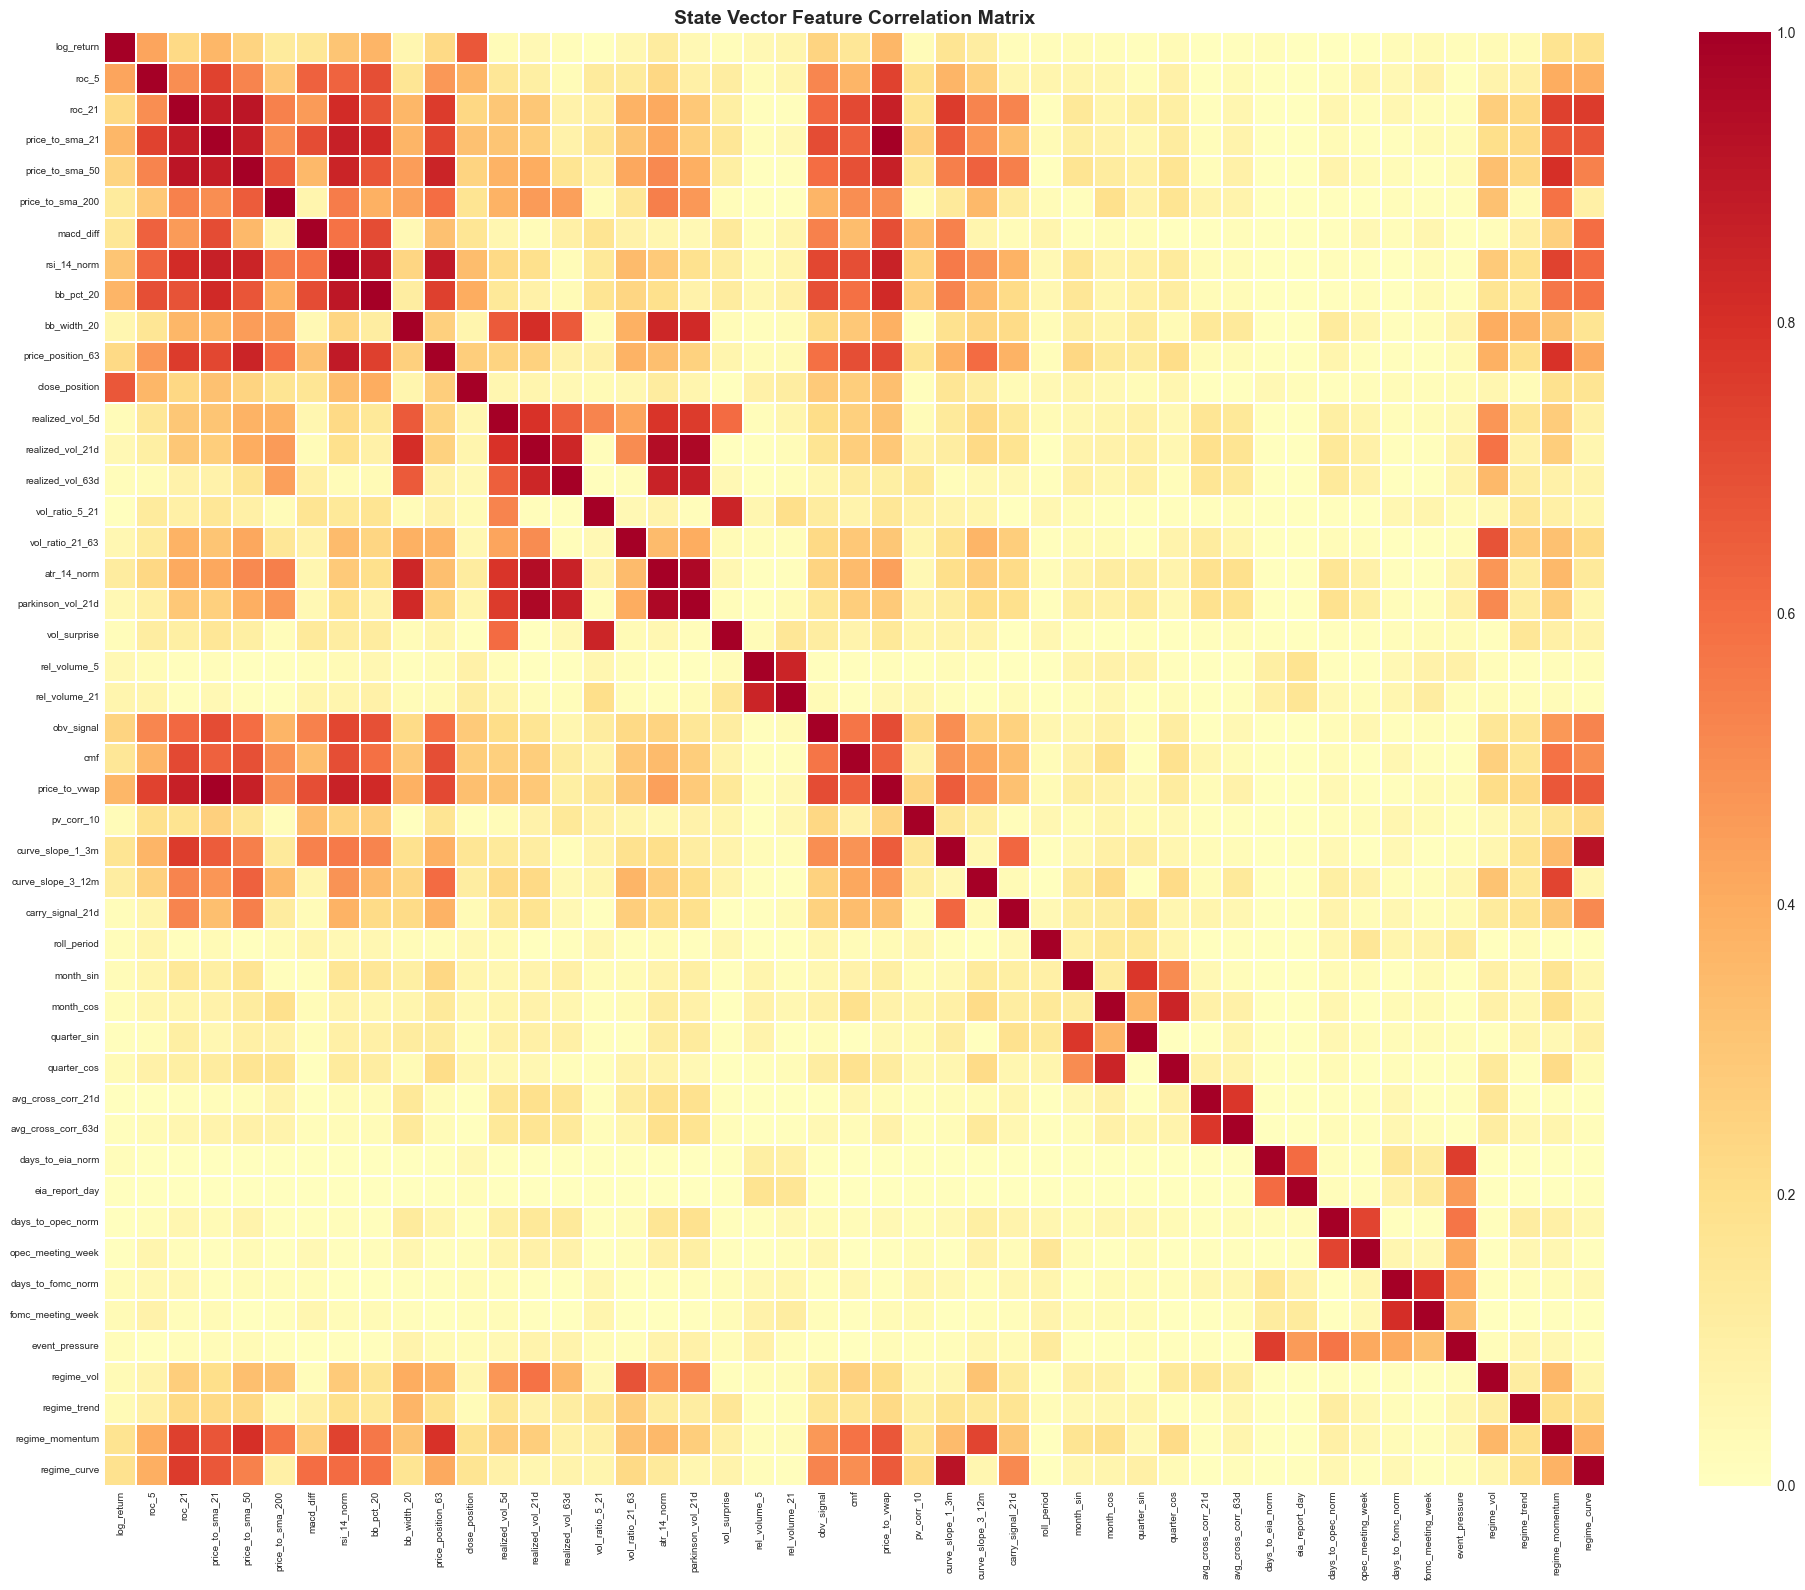

  Correlation heatmap saved to results\plots\state_vector_correlation.png

Features flagged as potentially redundant: 3
NOTE: These are reported for thesis documentation.
      Final feature set is ALL_FEATURES as defined above.
      The CNN encoder will learn to handle correlated inputs.


In [11]:
def analyze_feature_correlations(
    df           : pd.DataFrame,
    features     : list,
    threshold    : float = 0.95,
    save_path    : Path  = None
) -> list:
    """
    Identify and report highly correlated feature pairs.
    Returns list of features to consider dropping.

    Note: We report but do not auto-drop features.
    Final feature selection is a design decision documented in thesis.
    """
    # Use only rows where all features are available
    valid_features = [f for f in features if f in df.columns]
    df_feat = df[valid_features].dropna()

    if len(df_feat) < 100:
        print('Insufficient data for correlation analysis')
        return []

    corr_matrix = df_feat.corr().abs()

    # Find highly correlated pairs
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    high_corr_pairs = [
        (col, row, upper_tri.loc[row, col])
        for col in upper_tri.columns
        for row in upper_tri.index
        if upper_tri.loc[row, col] > threshold
    ]

    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

    print(f'\nFeature Correlation Analysis (threshold={threshold}):')
    print(f'  Features analyzed : {len(valid_features)}')
    print(f'  High corr pairs   : {len(high_corr_pairs)}')

    if high_corr_pairs:
        print(f'  Top correlated pairs:')
        for f1, f2, corr in high_corr_pairs[:10]:
            print(f'    {f1} <-> {f2}: {corr:.3f}')

    # Plot correlation heatmap for state vector features
    if save_path and len(valid_features) <= 50:
        fig, ax = plt.subplots(figsize=(20, 16))
        sns.heatmap(
            corr_matrix,
            cmap='RdYlGn_r',
            center=0,
            vmin=0, vmax=1,
            ax=ax,
            xticklabels=True,
            yticklabels=True,
            linewidths=0.1,
            annot=False
        )
        ax.set_title('State Vector Feature Correlation Matrix',
                      fontsize=14, fontweight='bold')
        plt.xticks(rotation=90, fontsize=7)
        plt.yticks(rotation=0, fontsize=7)
        plt.tight_layout()
        filepath = save_path / 'state_vector_correlation.png'
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Correlation heatmap saved to {filepath}')

    # Return features to potentially drop (keep lower index in list)
    to_drop = list(set([pair[1] for pair in high_corr_pairs]))
    return to_drop


# Run correlation analysis on WTI state vector
wti_df       = feature_data['WTI_Crude_Oil']
redundant    = analyze_feature_correlations(
    wti_df, ALL_FEATURES,
    threshold=0.95,
    save_path=RESULTS
)

print(f'\nFeatures flagged as potentially redundant: {len(redundant)}')
print('NOTE: These are reported for thesis documentation.')
print('      Final feature set is ALL_FEATURES as defined above.')
print('      The CNN encoder will learn to handle correlated inputs.')


Top 20 Features by Mutual Information with 1-day forward return:
          feature  mi_score
 realized_vol_21d    0.0914
      atr_14_norm    0.0871
parkinson_vol_21d    0.0857
 realized_vol_63d    0.0608
 price_to_sma_200    0.0550
      bb_width_20    0.0525
  realized_vol_5d    0.0512
  price_to_sma_21    0.0436
       regime_vol    0.0416
           roc_21    0.0400
  price_to_sma_50    0.0315
  vol_ratio_21_63    0.0310
              cmf    0.0307
       obv_signal    0.0302
curve_slope_3_12m    0.0289
            roc_5    0.0281
       log_return    0.0268
    price_to_vwap    0.0254
    rel_volume_21    0.0247
        bb_pct_20    0.0237


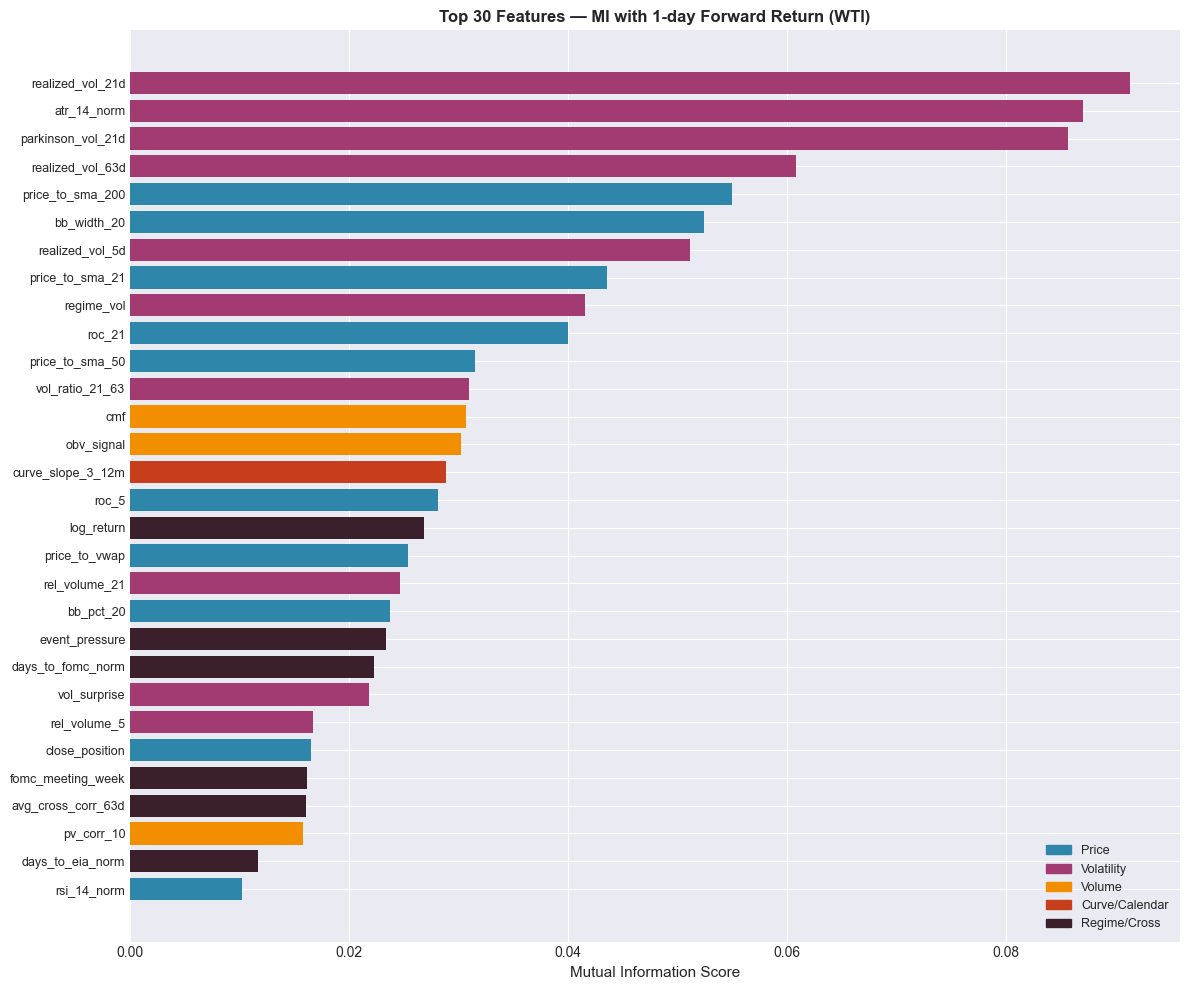

Saved to results\plots\feature_importance_horizon_1d.png

Top 20 Features by Mutual Information with 5-day forward return:
          feature  mi_score
parkinson_vol_21d    0.0854
      atr_14_norm    0.0835
 realized_vol_63d    0.0720
 realized_vol_21d    0.0523
      bb_width_20    0.0511
 price_to_sma_200    0.0482
  realized_vol_5d    0.0387
  price_to_sma_50    0.0325
       regime_vol    0.0321
           roc_21    0.0321
    price_to_vwap    0.0320
curve_slope_3_12m    0.0285
 days_to_eia_norm    0.0265
        month_cos    0.0257
  vol_ratio_21_63    0.0256
      rsi_14_norm    0.0244
  price_to_sma_21    0.0234
        month_sin    0.0209
            roc_5    0.0205
       log_return    0.0185


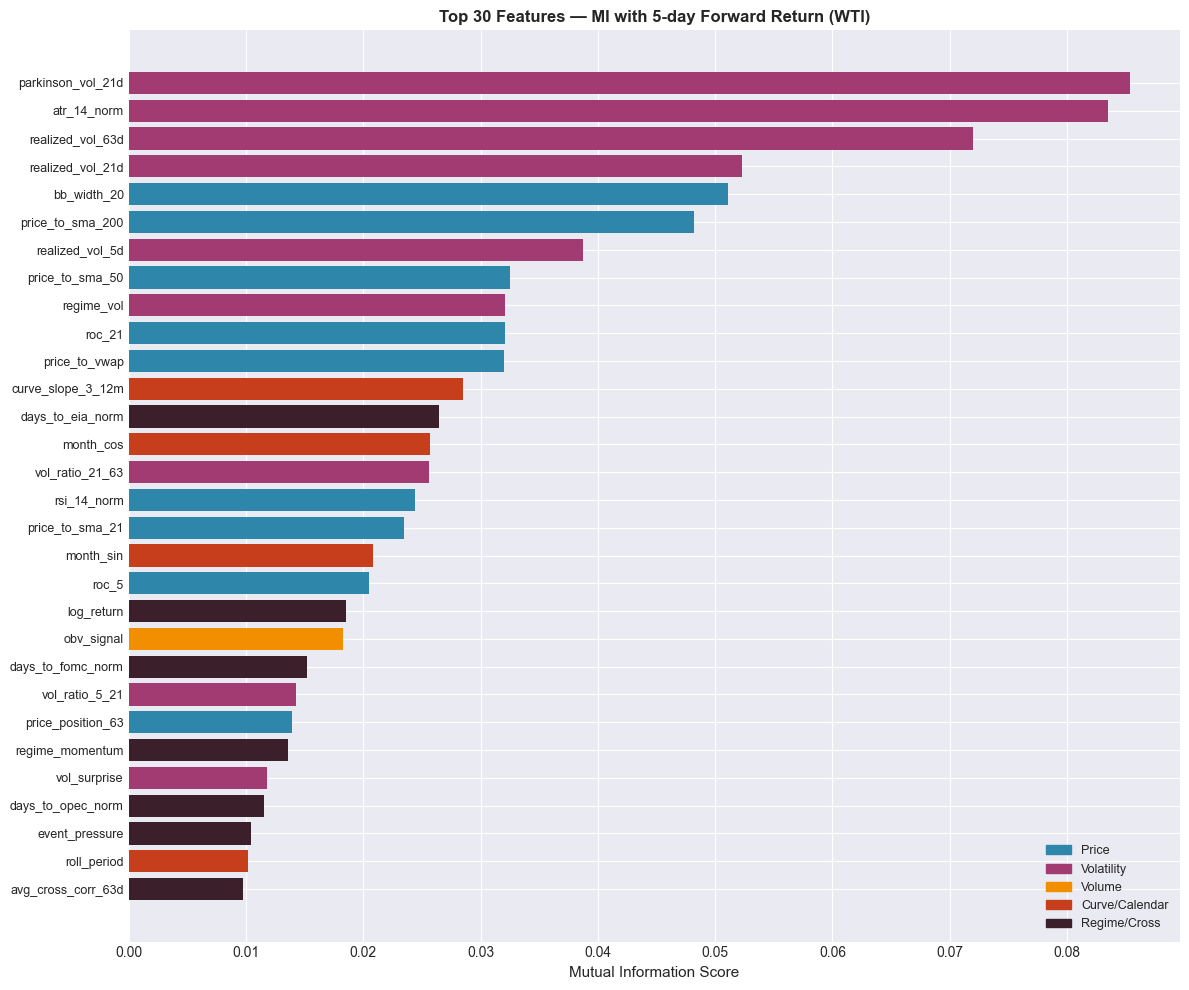

Saved to results\plots\feature_importance_horizon_5d.png


In [12]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

def compute_feature_importance(
    df        : pd.DataFrame,
    features  : list,
    target    : str = 'log_return',
    horizon   : int = 1,
    save_path : Path = None
) -> pd.DataFrame:
    """
    Compute mutual information between each feature and
    future returns at specified horizon.

    This provides an indication of which features carry
    predictive information, but does NOT drive feature
    selection — the agent learns its own feature weights.
    """
    valid_features = [f for f in features if f in df.columns]

    # Future return as target
    df_work = df[valid_features].copy()
    df_work['target'] = df[target].shift(-horizon)  # Forward return
    df_work = df_work.dropna()

    X = df_work[valid_features].values
    y = df_work['target'].values

    # Scale features for MI computation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Compute mutual information
    mi_scores = mutual_info_regression(
        X_scaled, y,
        random_state=42,
        n_neighbors=5
    )

    importance_df = pd.DataFrame({
        'feature'    : valid_features,
        'mi_score'   : mi_scores
    }).sort_values('mi_score', ascending=False)

    print(f'\nTop 20 Features by Mutual Information with {horizon}-day forward return:')
    print(importance_df.head(20).to_string(index=False))

    # Plot
    if save_path:
        fig, ax = plt.subplots(figsize=(12, 10))
        top_n = importance_df.head(30)
        colors = [
            '#2E86AB' if any(f in col for f in ['price', 'roc', 'sma', 'ema', 'macd', 'rsi', 'bb', 'stoch', 'cci', 'williams', 'position', 'gap', 'overnight'])
            else '#A23B72' if any(f in col for f in ['vol', 'atr', 'parkinson', 'gk'])
            else '#F18F01' if any(f in col for f in ['volume', 'obv', 'cmf', 'vwap', 'pv'])
            else '#C73E1D' if any(f in col for f in ['curve', 'carry', 'roll', 'month', 'quarter', 'dow'])
            else '#3B1F2B'
            for col in top_n['feature']
        ]

        bars = ax.barh(range(len(top_n)), top_n['mi_score'], color=colors)
        ax.set_yticks(range(len(top_n)))
        ax.set_yticklabels(top_n['feature'], fontsize=9)
        ax.set_xlabel('Mutual Information Score', fontsize=11)
        ax.set_title(f'Top 30 Features — MI with {horizon}-day Forward Return (WTI)',
                      fontsize=12, fontweight='bold')
        ax.invert_yaxis()

        # Legend
        from matplotlib.patches import Patch
        legend = [
            Patch(color='#2E86AB', label='Price'),
            Patch(color='#A23B72', label='Volatility'),
            Patch(color='#F18F01', label='Volume'),
            Patch(color='#C73E1D', label='Curve/Calendar'),
            Patch(color='#3B1F2B', label='Regime/Cross')
        ]
        ax.legend(handles=legend, loc='lower right', fontsize=9)

        plt.tight_layout()
        filepath = save_path / f'feature_importance_horizon_{horizon}d.png'
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved to {filepath}')

    return importance_df


# Run for WTI, 1-day and 5-day horizons
wti_df = feature_data['WTI_Crude_Oil']

importance_1d = compute_feature_importance(
    wti_df, ALL_FEATURES, horizon=1, save_path=RESULTS
)
importance_5d = compute_feature_importance(
    wti_df, ALL_FEATURES, horizon=5, save_path=RESULTS
)

# Save importance scores
importance_1d.to_csv(DATA_FEAT / 'feature_importance_1d.csv', index=False)
importance_5d.to_csv(DATA_FEAT / 'feature_importance_5d.csv', index=False)

In [13]:
def build_final_feature_dataset(
    df           : pd.DataFrame,
    features     : list,
    warmup_days  : int = 252
) -> pd.DataFrame:
    """
    Build the final feature dataset ready for the trading environment.

    Steps:
    1. Select only state vector features + OHLCV + metadata
    2. Remove warm-up period (first 252 days)
    3. Handle remaining NaNs with forward fill
    4. Verify no NaNs remain in feature columns
    5. Save

    IMPORTANT: No scaling applied here.
    Scaling happens in the environment per walk-forward window.
    """
    # Columns to keep: OHLCV + metadata + all features
    base_cols = ['open', 'high', 'low', 'close', 'volume',
             'log_return', 'simple_return',
             'momentum_1m', 'momentum_3m', 'momentum_6m', 'momentum_12m',
             'crisis_period', 'is_outlier', 'commodity']

    keep_cols = [c for c in base_cols if c in df.columns]
    feat_cols = [f for f in features if f in df.columns]

    all_cols = list(dict.fromkeys(keep_cols + feat_cols))  # Preserve order, no duplicates
    df_out   = df[all_cols].copy()

    # Remove warm-up period
    df_out = df_out.iloc[warmup_days:]

    # Forward fill any remaining NaNs in feature columns
    df_out[feat_cols] = df_out[feat_cols].fillna(method='ffill').fillna(0)

    # Verify
    remaining_nans = df_out[feat_cols].isnull().sum().sum()
    if remaining_nans > 0:
        print(f'  WARNING: {remaining_nans} NaNs remain in feature columns')
    else:
        print(f'  ✓ No NaNs in feature columns')

    return df_out


# ─── Build and Save Final Datasets ────────────────────────────────────────────
print('Building final feature datasets...')
final_data = {}

for name, df in feature_data.items():
    print(f'\n{name}:')
    final_df = build_final_feature_dataset(df, ALL_FEATURES, warmup_days=252)
    final_data[name] = final_df

    # Save individual commodity
    filepath = DATA_FEAT / f'{name}_features.parquet'
    final_df.to_parquet(filepath)
    print(f'  Saved: {len(final_df)} rows, {len(final_df.columns)} columns → {filepath}')

# Save combined dataset
combined_feat = pd.concat(list(final_data.values()), axis=0).sort_index()
combined_feat.to_parquet(DATA_FEAT / 'all_commodities_features.parquet')
print(f'\nCombined dataset: {len(combined_feat)} rows')

Building final feature datasets...

WTI_Crude_Oil:
  ✓ No NaNs in feature columns
  Saved: 4965 rows, 60 columns → data\features\WTI_Crude_Oil_features.parquet

Gold:
  ✓ No NaNs in feature columns
  Saved: 4965 rows, 60 columns → data\features\Gold_features.parquet

Natural_Gas:
  ✓ No NaNs in feature columns
  Saved: 4965 rows, 60 columns → data\features\Natural_Gas_features.parquet

Silver:
  ✓ No NaNs in feature columns
  Saved: 4965 rows, 60 columns → data\features\Silver_features.parquet

Copper:
  ✓ No NaNs in feature columns
  Saved: 4965 rows, 60 columns → data\features\Copper_features.parquet

Combined dataset: 24825 rows


In [14]:
import json
import yaml

# ─── Save Feature Configuration ───────────────────────────────────────────────
feature_config = {
    'state_vector_features' : STATE_VECTOR_FEATURES,
    'all_features'          : ALL_FEATURES,
    'n_features'            : len(ALL_FEATURES),
    'feature_groups'        : {
        group: len(feats)
        for group, feats in STATE_VECTOR_FEATURES.items()
    },
    'regime_features'       : STATE_VECTOR_FEATURES['regime'],
    'warmup_days'           : 252,
    'lookback_window'       : 60,   # Days of history fed to LSTM
    'input_shape'           : [60, len(ALL_FEATURES)]
}

# Save as JSON for Python consumption
with open(DATA_FEAT / 'feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

# Save as YAML for configs directory
from pathlib import Path
configs_dir = Path('.') / 'configs'
configs_dir.mkdir(exist_ok=True)

with open(configs_dir / 'features.yaml', 'w') as f:
    yaml.dump(feature_config, f, default_flow_style=False)

print('Feature configuration saved:')
print(f'  data/features/feature_config.json')
print(f'  configs/features.yaml')

# ─── Final Summary ────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('NOTEBOOK 02 COMPLETE')
print('='*60)

print('\nFeature Engineering Summary:')
for group, feats in STATE_VECTOR_FEATURES.items():
    print(f'  {group:20s}: {len(feats):3d} features')
print(f'  {"TOTAL":20s}: {len(ALL_FEATURES):3d} features')

print(f'\nCNN-LSTM Input Shape: (batch_size, 60, {len(ALL_FEATURES)})')
print(f'Regime Gating Features: {STATE_VECTOR_FEATURES["regime"]}')

print('\nOutputs saved:')
print(f'  data/features/  → {len(final_data)} commodity feature files')
print(f'                  → all_commodities_features.parquet')
print(f'                  → feature_config.json')
print(f'                  → feature_importance_1d.csv')
print(f'                  → feature_importance_5d.csv')
print(f'  configs/        → features.yaml')
print(f'  results/plots/  → correlation heatmap, importance plots')

print('\nNext: Run 03_trading_environment.ipynb')

Feature configuration saved:
  data/features/feature_config.json
  configs/features.yaml

NOTEBOOK 02 COMPLETE

Feature Engineering Summary:
  price               :  12 features
  volatility          :   8 features
  volume              :   6 features
  curve               :   8 features
  cross_commodity     :   2 features
  calendar            :   7 features
  regime              :   4 features
  TOTAL               :  47 features

CNN-LSTM Input Shape: (batch_size, 60, 47)
Regime Gating Features: ['regime_vol', 'regime_trend', 'regime_momentum', 'regime_curve']

Outputs saved:
  data/features/  → 5 commodity feature files
                  → all_commodities_features.parquet
                  → feature_config.json
                  → feature_importance_1d.csv
                  → feature_importance_5d.csv
  configs/        → features.yaml
  results/plots/  → correlation heatmap, importance plots

Next: Run 03_trading_environment.ipynb
